## 初期ロード

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
train_df = pd.read_csv(Path(r"../data/train.csv"))
test_df = pd.read_csv(Path(r"../data/test.csv"))

print(train_df.shape, test_df.shape)

(1460, 81) (1459, 80)


In [3]:
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
df_tmp_feats = train_df[['LotArea','GrLivArea','OverallQual']]
df_tmp_feats

,LotArea,GrLivArea,OverallQual
0,8450,1710,7
1,9600,1262,6
2,11250,1786,7
3,9550,1717,7
4,14260,2198,8
...,...,...,...
1455,7917,1647,6
1456,13175,2073,6
1457,9042,2340,7
1458,9717,1078,5


In [9]:
df_tmp_feats['LotArea'] = np.log1p(df_tmp_feats['LotArea'])
df_tmp_feats['GrLivArea'] = np.log1p(df_tmp_feats['GrLivArea'])

In [12]:
scaler = StandardScaler()
df_std = pd.DataFrame(
    data=scaler.fit_transform(df_tmp_feats.values),
    columns=df_tmp_feats.columns.to_list())
df_std

,LotArea,GrLivArea,OverallQual
0,-0.106497,0.542547,0.689072
1,0.137375,-0.363866,0.027742
2,0.436287,0.669632,0.689072
3,0.127455,0.554514,0.689072
4,0.874672,1.267459,1.272406
...,...,...,...
1455,-0.232221,0.432319,0.027742
1456,0.729448,1.100275,0.027742
1457,0.023306,1.444979,0.689072
1458,0.160369,-0.847377,-0.735707


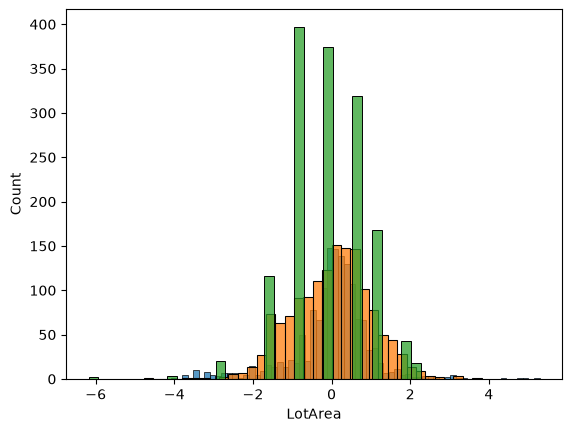

In [18]:
for c in df_std.columns:
    sns.histplot(data=df_std[c])